In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from mlxtend.plotting import plot_decision_regions
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score
from sklearn.naive_bayes import GaussianNB, MultinomialNB,BernoulliNB

In [22]:
dataset = pd.read_csv("../datasets/cgpa_score_placement.csv")
dataset.head()


,cgpa,score,placed
0,6.69,7.89,1
1,9.28,5.38,1
2,8.29,5.73,1
3,7.69,9.04,1
4,5.70,7.73,1


In [23]:
dataset.isnull().sum()

cgpa      0
score     0
placed    0
dtype: int64

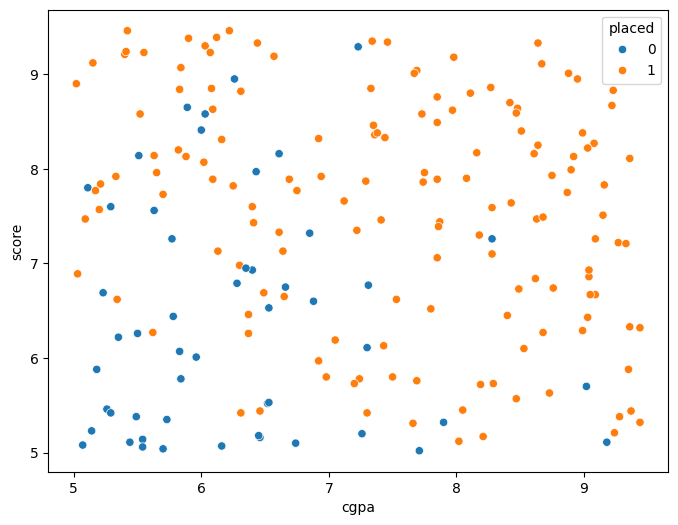

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="cgpa",y="score",data=dataset,hue="placed")
plt.show()

In [25]:
x =dataset.iloc[:,:-1]
y=dataset['placed']
print(x,y)

     cgpa  score
0    6.69   7.89
1    9.28   5.38
2    8.29   5.73
3    7.69   9.04
4    5.70   7.73
..    ...    ...
195  6.57   9.19
196  8.27   8.86
197  9.04   6.93
198  8.99   8.38
199  8.51   8.40

[200 rows x 2 columns] 0      1
1      1
2      1
3      1
4      1
      ..
195    1
196    1
197    1
198    1
199    1
Name: placed, Length: 200, dtype: int64


In [26]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=52)

<Axes: xlabel='cgpa', ylabel='Density'>

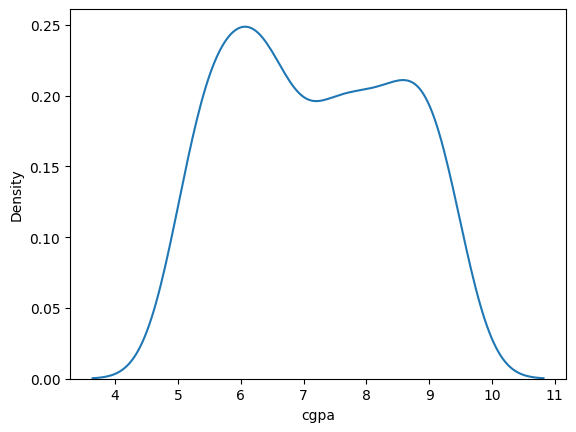

In [27]:
sns.kdeplot(data=dataset["cgpa"])

In [28]:
gnb = GaussianNB()
gnb.fit(x_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [29]:
gnb.score(x_test,y_test)*100,gnb.score(x_train,y_train)*100

(82.5, 82.5)

In [37]:
gnb.predict([[6.69,7.89]])

c:\Users\HP\Desktop\Projects\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


array([1])

c:\Users\HP\Desktop\Projects\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


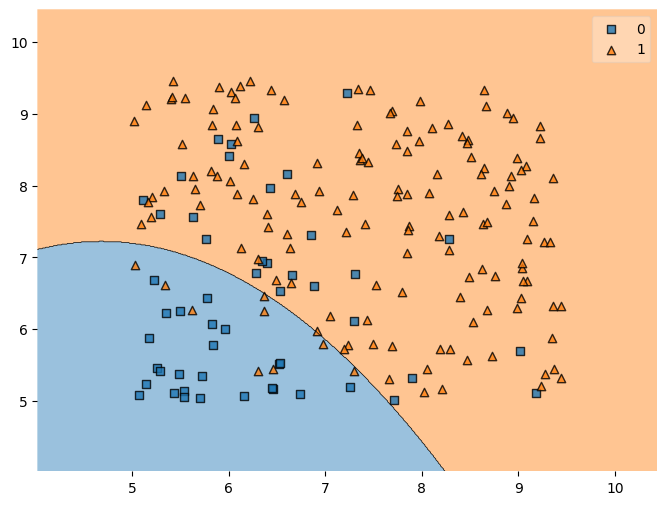

In [30]:
plt.figure(figsize=(8,6))

plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=gnb)
plt.show()

In [31]:
mnb = MultinomialNB()
mnb.fit(x_train,y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [32]:
mnb.score(x_test,y_test)*100,mnb.score(x_train,y_train)*100

(77.5, 73.75)

c:\Users\HP\Desktop\Projects\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


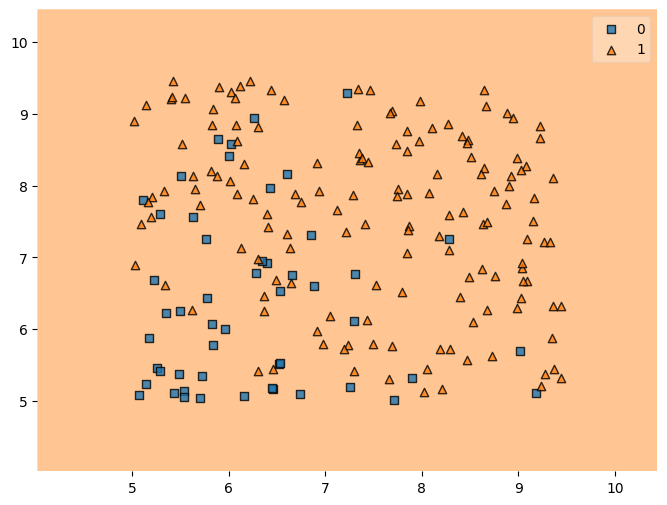

In [33]:
plt.figure(figsize=(8,6))
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=mnb)
plt.show()

In [34]:
bnb = BernoulliNB()
bnb.fit(x_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [35]:
bnb.score(x_test,y_test)*100,bnb.score(x_train,y_train)*100

(77.5, 73.75)

c:\Users\HP\Desktop\Projects\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


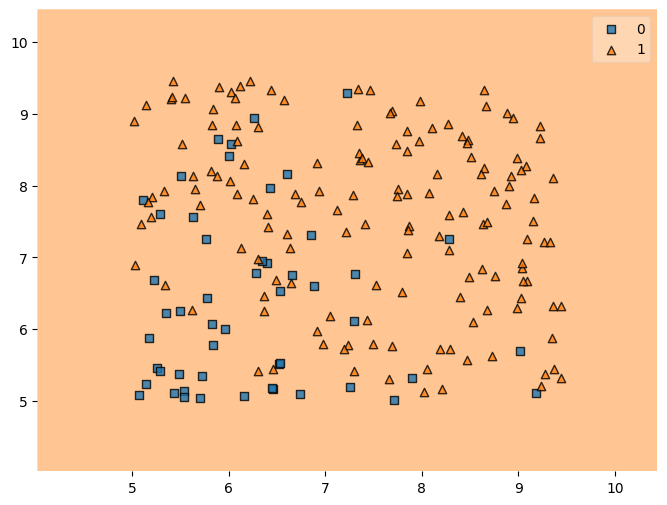

In [36]:
plt.figure(figsize=(8,6))
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=bnb)
plt.show()